In [41]:
# Retail Sales Analysis — 2024
#Analyst: Pratiksha Dandriyal  
#Date: June 2026  
#Tool: Python (Pandas, Matplotlib)

## Business Problem
#The sales manager needs to understand category performance, monthly trends, and return rates before the Monday review meeting.

In [43]:
# 1. Data Loading & Audit
#Initial inspection of raw data for shape, dtypes, and quality issues.

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'order_id':    range(1001, 1001 + n),
    'order_date':  pd.date_range('2024-01-01', periods=n, freq='D').strftime('%d-%m-%Y'),
    'customer_id': np.random.randint(200, 350, n),
    'category':    np.random.choice(['Electronics', 'Clothing', 'Groceries', 'Furniture', None], n, p=[0.25, 0.25, 0.25, 0.20, 0.05]),
    'quantity':    np.random.randint(1, 10, n),
    'unit_price':  np.round(np.random.uniform(50, 5000, n), 2),
    'discount':    np.random.choice([0, 0.05, 0.10, 0.20, None], n, p=[0.5, 0.2, 0.15, 0.1, 0.05]),
    'region':      np.random.choice(['North', 'South', 'East', 'West'], n),
    'returned':    np.random.choice([True, False], n, p=[0.1, 0.9])
})

# Intentional data quality issues (realistic!)
df.loc[10:15, 'unit_price'] = -99       # negative prices
df.loc[30:32, 'quantity']   = 0         # zero quantity orders
df.loc[50, 'order_date']    = '2024-13-01'  # invalid date

df.to_csv('retail_sales.csv', index=False)
print(df.shape)
print(df.dtypes)

(500, 9)
order_id         int64
order_date      object
customer_id      int32
category        object
quantity         int32
unit_price     float64
discount        object
region          object
returned          bool
dtype: object


In [4]:
df = pd.read_csv('retail_sales.csv')
df.head(10)

,order_id,order_date,customer_id,category,quantity,unit_price,discount,region,returned
0,1001,01-01-2024,302,Groceries,5,2960.03,0.05,South,False
1,1002,02-01-2024,292,Furniture,9,4745.49,0.00,West,False
2,1003,03-01-2024,214,Furniture,6,1300.01,0.05,South,False
3,1004,04-01-2024,306,Electronics,7,1828.29,0.05,West,False
4,1005,05-01-2024,271,Furniture,5,1927.83,0.10,East,False
5,1006,06-01-2024,220,Groceries,6,3047.41,0.10,East,True
6,1007,07-01-2024,302,Clothing,5,1815.82,0.10,East,False
7,1008,08-01-2024,321,Groceries,9,2690.88,0.00,East,False
8,1009,09-01-2024,274,Clothing,6,3919.86,0.10,East,False
9,1010,10-01-2024,287,Clothing,8,3541.66,0.10,South,False


In [7]:
df = pd.read_csv('retail_sales.csv')
df.tail(10)

,order_id,order_date,customer_id,category,quantity,unit_price,discount,region,returned
490,1491,05-05-2025,273,Clothing,8,3721.47,0.00,East,False
491,1492,06-05-2025,344,Electronics,8,4413.18,0.00,West,False
492,1493,07-05-2025,206,Furniture,4,1425.62,0.05,North,False
493,1494,08-05-2025,340,Groceries,7,1010.07,0.05,South,False
494,1495,09-05-2025,336,Groceries,3,4405.09,0.00,North,False
495,1496,10-05-2025,226,Furniture,6,3304.92,0.05,North,False
496,1497,11-05-2025,321,Groceries,9,1589.10,0.00,South,False
497,1498,12-05-2025,204,Furniture,1,3724.62,0.10,West,False
498,1499,13-05-2025,228,Clothing,5,4084.84,0.20,East,False
499,1500,14-05-2025,282,Electronics,4,3094.14,0.00,West,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     500 non-null    int64  
 1   order_date   500 non-null    object 
 2   customer_id  500 non-null    int64  
 3   category     480 non-null    object 
 4   quantity     500 non-null    int64  
 5   unit_price   500 non-null    float64
 6   discount     475 non-null    float64
 7   region       500 non-null    object 
 8   returned     500 non-null    bool   
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 31.9+ KB


In [9]:
df.isnull().sum()

order_id        0
order_date      0
customer_id     0
category       20
quantity        0
unit_price      0
discount       25
region          0
returned        0
dtype: int64

In [10]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount
count,500.000000,500.000000,500.00000,500.000000,475.000000
mean,1250.500000,277.104000,4.97400,2446.278740,0.046421
std,144.481833,43.983067,2.66073,1413.280786,0.062117
min,1001.000000,200.000000,0.00000,-99.000000,0.000000
25%,1125.750000,238.000000,3.00000,1201.482500,0.000000
50%,1250.500000,281.500000,5.00000,2461.665000,0.000000
75%,1375.250000,315.000000,7.00000,3656.907500,0.100000
max,1500.000000,349.000000,9.00000,4977.630000,0.200000


In [45]:
# 2. Data Cleaning
# Issues found and fixes applied:
# - 6 rows with negative unit prices → dropped
# - 3 rows with zero quantity → dropped  
# - 1 row with invalid date (month 13) → dropped
# - 20 rows with missing category → dropped
# - 25 rows with missing discount → filled with 0 (assumption: no discount applied)

# **Rows retained: 470 / 500 (94%)**

In [12]:
# How many are there?
print(df[df['unit_price'] < 0].shape[0])



0


In [13]:
# Fix: drop those rows
df = df[df['unit_price'] > 0]
print("After fix:", df.shape)

After fix: (494, 9)


In [14]:
print(df[df['quantity'] == 0].shape[0])

3


In [16]:
df = df[df['quantity'] > 0]
print("After fix:", df.shape)

After fix: (491, 9)


In [18]:
df['order_date'] = pd.to_datetime(df['order_date'], 
                                   format='%d-%m-%Y', 
                                   errors='coerce')  # invalid → NaT

In [19]:
# How many dates failed to parse?
print("Invalid dates:", df['order_date'].isnull().sum())

# Drop that row too
df = df[df['order_date'].notna()]
print("After fix:", df.shape)

Invalid dates: 1
After fix: (490, 9)


In [20]:
# Drop rows where category is missing
df = df.dropna(subset=['category'])
print("After category drop:", df.shape)

After category drop: (470, 9)


In [21]:
# Fill missing discount with 0
df['discount'] = df['discount'].fillna(0)

In [22]:
# Verify no missing values remain
print(df.isnull().sum())

order_id       0
order_date     0
customer_id    0
category       0
quantity       0
unit_price     0
discount       0
region         0
returned       0
dtype: int64


In [23]:
print("Final shape:", df.shape)
print("Date range:", df['order_date'].min(), "to", df['order_date'].max())
print("Categories:", df['category'].unique())

Final shape: (470, 9)
Date range: 2024-01-01 00:00:00 to 2025-05-14 00:00:00
Categories: ['Groceries' 'Furniture' 'Electronics' 'Clothing']


In [ ]:
# ## 3. Feature Engineering
# - `revenue` = quantity × unit_price × (1 − discount)
# - Extracted `month`, `year`, `month_name` from order_date

In [24]:
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
df['revenue'] = df['revenue'].round(2)

# Sanity check
print(df[['quantity', 'unit_price', 'discount', 'revenue']].head())

   quantity  unit_price  discount   revenue
0         5     2960.03      0.05  14060.14
1         9     4745.49      0.00  42709.41
2         6     1300.01      0.05   7410.06
3         7     1828.29      0.05  12158.13
4         5     1927.83      0.10   8675.24


In [25]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year
df['month_name'] = df['order_date'].dt.strftime('%b')

print(df[['order_date', 'month', 'year', 'month_name']].head())

  order_date  month  year month_name
0 2024-01-01      1  2024        Jan
1 2024-01-02      1  2024        Jan
2 2024-01-03      1  2024        Jan
3 2024-01-04      1  2024        Jan
4 2024-01-05      1  2024        Jan


In [26]:
category_revenue = df.groupby('category')['revenue'].agg(
    total_revenue='sum',
    avg_revenue='mean',
    order_count='count'
).round(2).sort_values('total_revenue', ascending=False)

print(category_revenue)

             total_revenue  avg_revenue  order_count
category                                            
Groceries       1511220.77     10950.88          138
Electronics     1408350.01     12803.18          110
Clothing        1359306.51     11327.55          120
Furniture       1229663.19     12055.52          102


In [27]:
monthly_revenue = df.groupby(['year', 'month', 'month_name'])['revenue'].sum().round(2)
monthly_revenue = monthly_revenue.reset_index().sort_values(['year', 'month'])

print(monthly_revenue.to_string(index=False))

 year  month month_name   revenue
 2024      1        Jan 296176.97
 2024      2        Feb 276848.29
 2024      3        Mar 394306.17
 2024      4        Apr 379060.49
 2024      5        May 317186.39
 2024      6        Jun 350658.41
 2024      7        Jul 408941.94
 2024      8        Aug 361280.70
 2024      9        Sep 281738.07
 2024     10        Oct 300512.33
 2024     11        Nov 302947.39
 2024     12        Dec 362912.08
 2025      1        Jan 357331.69
 2025      2        Feb 338083.09
 2025      3        Mar 278828.13
 2025      4        Apr 317987.07
 2025      5        May 183741.27


In [28]:
# Returned orders - how much revenue is at risk?
returned = df[df['returned'] == True]
print("Returned orders:", len(returned))
print("Revenue at risk:", returned['revenue'].sum().round(2))
print("% of total revenue:", round(returned['revenue'].sum() / df['revenue'].sum() * 100, 2), "%")

Returned orders: 47
Revenue at risk: 596207.33
% of total revenue: 10.82 %


In [34]:
monthly_revenue = df.groupby(['year', 'month', 'month_name'])['revenue'].sum().round(2)
monthly_revenue = monthly_revenue.reset_index().sort_values(['month', 'revenue'], ascending=False)

print(monthly_revenue.to_string(index=False))

 year  month month_name   revenue
 2024     12        Dec 362912.08
 2024     11        Nov 302947.39
 2024     10        Oct 300512.33
 2024      9        Sep 281738.07
 2024      8        Aug 361280.70
 2024      7        Jul 408941.94
 2024      6        Jun 350658.41
 2024      5        May 317186.39
 2025      5        May 183741.27
 2024      4        Apr 379060.49
 2025      4        Apr 317987.07
 2024      3        Mar 394306.17
 2025      3        Mar 278828.13
 2025      2        Feb 338083.09
 2024      2        Feb 276848.29
 2025      1        Jan 357331.69
 2024      1        Jan 296176.97


In [35]:
print(df['revenue'].sum())
print(category_revenue)

5508540.48
             total_revenue  avg_revenue  order_count
category                                            
Groceries       1511220.77     10950.88          138
Electronics     1408350.01     12803.18          110
Clothing        1359306.51     11327.55          120
Furniture       1229663.19     12055.52          102


In [ ]:
# 4. Analysis & Findings

# Key Findings
# 1. **Groceries** leads in total revenue (₹15.1L) driven by highest order volume (138 orders)
# 2. **Electronics** has the highest average order value (₹12,803) — fewer but bigger purchases
# 3. **July 2024** was the strongest month
# 4. **10.8% of revenue** is at risk from returns — low but worth monitoring

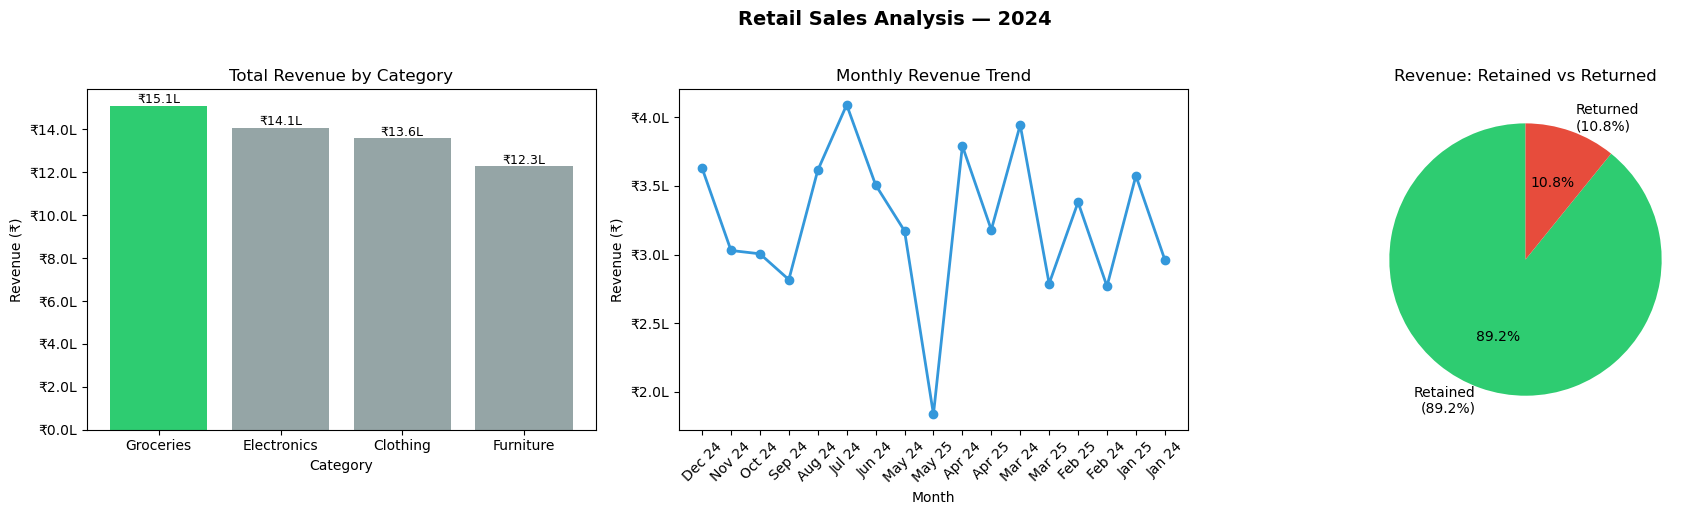

Chart saved.


In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Retail Sales Analysis — 2024', fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Revenue by Category ──────────────────────────
colors = ['#2ecc71' if c == 'Groceries' else '#95a5a6' for c in category_revenue.index]
axes[0].bar(category_revenue.index, category_revenue['total_revenue'], color=colors)
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L'))
for i, v in enumerate(category_revenue['total_revenue']):
    axes[0].text(i, v + 10000, f'₹{v/100000:.1f}L', ha='center', fontsize=9)

# ── Chart 2: Monthly Revenue Trend ────────────────────────
monthly_revenue['label'] = monthly_revenue['month_name'] + ' ' + monthly_revenue['year'].astype(str).str[-2:]
axes[1].plot(monthly_revenue['label'], monthly_revenue['revenue'], 
             marker='o', color='#3498db', linewidth=2)
axes[1].set_title('Monthly Revenue Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L'))
axes[1].tick_params(axis='x', rotation=45)

# ── Chart 3: Returns Impact ────────────────────────────────
return_data = df.groupby('returned')['revenue'].sum()
labels = ['Retained\n(89.2%)', 'Returned\n(10.8%)']
axes[2].pie(return_data.values, labels=labels, 
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Revenue: Retained vs Returned')

plt.tight_layout()
plt.savefig('retail_sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [46]:
# ## 5. Recommendations
# 1. Investigate why Furniture has both lowest volume and lowest revenue
# 2. Replicate July conditions — was there a promotion? Stock availability?
# 3. Set a return rate alert if it crosses 15%

In [47]:
# Add this as your very last code cell
df.to_csv('retail_sales_clean.csv', index=False)
print("Clean dataset saved.")
print(f"Final shape: {df.shape}")
print(f"Total Revenue: ₹{df['revenue'].sum():,.2f}")

Clean dataset saved.
Final shape: (470, 13)
Total Revenue: ₹5,508,540.48
